In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('Consumer_Complaints.csv')

In [6]:
df.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,3/12/2014,Mortgage,Other mortgage,"Loan modification,collection,foreclosure",NaN,NaN,NaN,M&T BANK CORPORATION,MI,48382,NaN,NaN,Referral,3/17/2014,Closed with explanation,Yes,No,759217
1,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10/5/2016,Closed with explanation,Yes,No,2141773
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100
3,6/8/2014,Credit card,NaN,Bankruptcy,NaN,NaN,NaN,AMERICAN EXPRESS COMPANY,ID,83854,Older American,NaN,Web,6/10/2014,Closed with explanation,Yes,Yes,885638
4,9/13/2014,Debt collection,Credit card,Communication tactics,Frequent or repeated calls,NaN,NaN,"CITIBANK, N.A.",VA,23233,NaN,NaN,Web,9/13/2014,Closed with explanation,Yes,Yes,1027760


In [7]:
df.columns.tolist()

['Date received',
 'Product',
 'Sub-product',
 'Issue',
 'Sub-issue',
 'Consumer complaint narrative',
 'Company public response',
 'Company',
 'State',
 'ZIP code',
 'Tags',
 'Consumer consent provided?',
 'Submitted via',
 'Date sent to company',
 'Company response to consumer',
 'Timely response?',
 'Consumer disputed?',
 'Complaint ID']

In [8]:
df.shape

(903983, 18)

In [9]:
df = df.rename(columns={
    'Date received': 'date_received',
    'Product': 'product',
    'Sub-product': 'subproduct',
    'Issue': 'issue',
    'Sub-issue': 'subissue',
    'Consumer complaint narrative': 'complaint_text',
    'Company public response': 'company_public_response',
    'Company': 'company_name',
    'State': 'state',
    'ZIP code': 'zip_code',
    'Tags': 'tags',
    'Consumer consent provided?': 'consumer_consent_provided',
    'Submitted via': 'submitted_via',
    'Date sent to company': 'date_sent_to_company',
    'Company response to consumer': 'company_response_to_consumer',
    'Timely response?': 'timely_response',
    'Consumer disputed?': 'consumer_disputed',
    'Complaint ID': 'complaint_id'
})


In [11]:
df.columns.tolist()

['date_received',
 'product',
 'subproduct',
 'issue',
 'subissue',
 'complaint_text',
 'company_public_response',
 'company_name',
 'state',
 'zip_code',
 'tags',
 'consumer_consent_provided',
 'submitted_via',
 'date_sent_to_company',
 'company_response_to_consumer',
 'timely_response',
 'consumer_disputed',
 'complaint_id']

In [12]:
df['complaint_text'].notna().sum()

199970

In [13]:
df_nlp = df[df['complaint_text'].notna()].copy()

In [14]:
df_nlp.shape

(199970, 18)

In [15]:
df_nlp = df_nlp[df_nlp['complaint_text'].str.strip().ne('')]

In [16]:
df_nlp.shape

(199970, 18)

In [17]:
import re

def cleanText(text):
    text = text.lower()
    text = re.sub(r'\s+' , ' ', text)
    text= re.sub('r\n+' , ' ', text)
    return text.strip()

In [18]:
boilerplate_patterns = [
    r'thank you for your (help|assistance)',
    r'i am writing (this )?complaint',
    r'please help',
    r'please assist'
]

def remove_boilerplates(text):
    for pattern in boilerplate_patterns:
        text = re.sub(pattern , '', text);
    return text.strip()

In [23]:
df_nlp['clean_text'] = df_nlp['complaint_text'].apply(cleanText)

In [29]:
df_nlp['clean_text'] = df_nlp['complaint_text'].apply(remove_boilerplates)

In [34]:
df_nlp['text_len'] = df_nlp['complaint_text'].str.split().apply(len)

In [35]:
df_nlp.head()

,date_received,product,subproduct,issue,subissue,complaint_text,company_public_response,company_name,state,zip_code,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id,clean_text,text_len
1,10/1/2016,Credit reporting,NaN,Incorrect information on credit report,Account status,I have outdated information on my credit repor...,Company has responded to the consumer and the ...,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AL,352XX,NaN,Consent provided,Web,10/5/2016,Closed with explanation,Yes,No,2141773,I have outdated information on my credit repor...,34
2,10/17/2016,Consumer Loan,Vehicle loan,Managing the loan or lease,NaN,I purchased a new car on XXXX XXXX. The car de...,NaN,"CITIZENS FINANCIAL GROUP, INC.",PA,177XX,Older American,Consent provided,Web,10/20/2016,Closed with explanation,Yes,No,2163100,I purchased a new car on XXXX XXXX. The car de...,394
7,6/15/2015,Credit reporting,NaN,Credit reporting company's investigation,Inadequate help over the phone,An account on my credit report has a mistaken ...,Company chooses not to provide a public response,Experian Information Solutions Inc.,VA,224XX,NaN,Consent provided,Web,6/15/2015,Closed with explanation,Yes,No,1420702,An account on my credit report has a mistaken ...,212
12,2/3/2016,Debt collection,"Other (i.e. phone, health club, etc.)",Disclosure verification of debt,Not given enough info to verify debt,This company refuses to provide me verificatio...,NaN,"The CBE Group, Inc.",TX,752XX,NaN,Consent provided,Web,2/3/2016,Closed with explanation,Yes,Yes,1772196,This company refuses to provide me verificatio...,25
16,2/17/2016,Debt collection,Credit card,Improper contact or sharing of info,Talked to a third party about my debt,This complaint is in regards to Square Two Fin...,Company has responded to the consumer and the ...,SQUARETWO FINANCIAL CORPORATION,NE,693XX,NaN,Consent provided,Web,3/4/2016,Closed with explanation,Yes,Yes,1790634,This complaint is in regards to Square Two Fin...,309


In [36]:
df_nlp = df_nlp[df_nlp['text_len']>=20]

In [37]:
df_nlp.shape

(193297, 20)

In [38]:
df_nlp = df_nlp.drop_duplicates(subset='clean_text')

In [39]:
df_nlp.shape

(189109, 20)

In [52]:
df_nlp['clean_text'].sample(10, random_state=42).tolist()

['This account was sent to collections and judged upon where it was paid in full. There is a balance of {$21.00} showing. It should be {$0.00}.',
 "I have  XXXX  bankruptcies on my record that are not mine I 've sent in letters showed proof they advised they verify through  XXXX   XXXX  who advised they have NO RECORDS on file for me. I have filed many many disputes now it will be here and better business bureau",
 "I contacted by XXXX XXXX regarding an XXXX account balance that I disputed with XXXX, this past XXXX 2015. I had previously made a partial payment to RGE days before I was contacted by XXXX XXXX. When I spoke to the customer service rep at XXXX XXXX, I gave them all the information to debit my checking account for the remaining balance. I was told that they would first have to verify with RGE of the amount that I had already paid, and it might take as long as 30 days to confirm. They would then debit my account for the balance. I questioned whether the collection informatio

In [54]:

df_nlp['date_received'] = pd.to_datetime(
    df_nlp['date_received'],
    errors='coerce'
)


In [56]:
df_nlp['date_received'].isna().sum()

0

In [58]:
df_nlp['year'] = df_nlp['date_received'].dt.year
df_nlp['month'] = df_nlp['date_received'].dt.to_period('M')
df_nlp['week'] = df_nlp['date_received'].dt.to_period('W')

In [60]:
df_nlp[['year','month','week']].head()

,year,month,week
1,2016,2016-10,2016-09-26/2016-10-02
2,2016,2016-10,2016-10-17/2016-10-23
7,2015,2015-06,2015-06-15/2015-06-21
12,2016,2016-02,2016-02-01/2016-02-07
16,2016,2016-02,2016-02-15/2016-02-21


In [64]:
df_nlp['year'].value_counts().sort_index()

year
2015    51935
2016    74089
2017    63085
Name: count, dtype: int64

<Axes: title={'center': 'Complaints per Month'}, xlabel='month'>

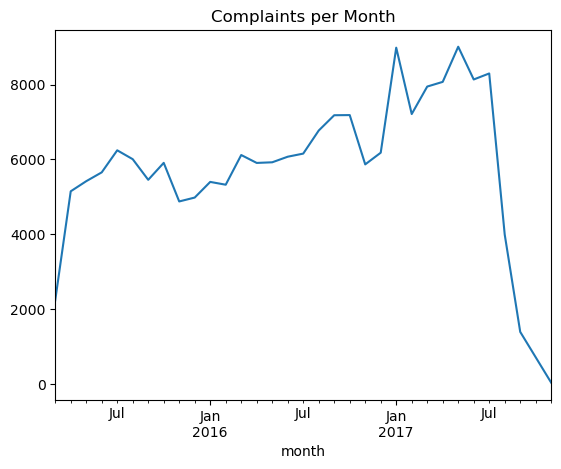

In [66]:
complaints_per_month = df_nlp.groupby('month').size()
complaints_per_month.plot(title = 'Complaints per Month')

<Axes: title={'center': 'Complaints per Week'}, xlabel='week'>

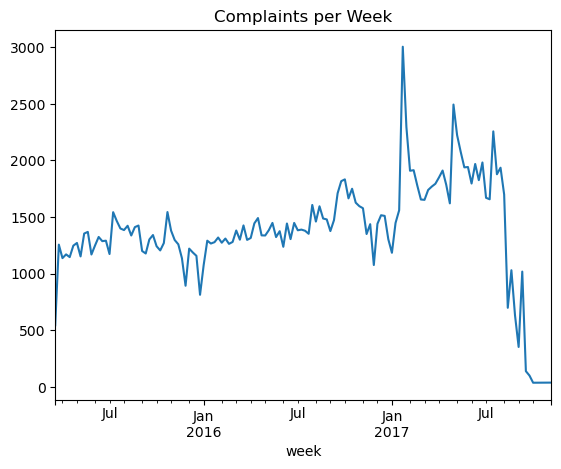

In [68]:
complaints_per_week = df_nlp.groupby('week').size()
complaints_per_week.plot(title = 'Complaints per Week')

In [74]:
df_nlp['product'].value_counts().head(30)

product
Debt collection                                                                 44615
Mortgage                                                                        36167
Credit reporting                                                                27944
Credit card                                                                     18337
Bank account or service                                                         14624
Student loan                                                                    13071
Credit reporting, credit repair services, or other personal consumer reports    12743
Consumer Loan                                                                    9225
Credit card or prepaid card                                                      3311
Checking or savings account                                                      2064
Payday loan                                                                      1682
Money transfers                               

In [76]:
product_mapping = {
    # Debt
    'Debt collection': 'Debt Collection',

    # Mortgage
    'Mortgage': 'Mortgage',

    # Credit reporting
    'Credit reporting': 'Credit Reporting',
    'Credit reporting, credit repair services, or other personal consumer reports': 'Credit Reporting',

    # Credit cards
    'Credit card': 'Credit Card',
    'Credit card or prepaid card': 'Credit Card',
    'Prepaid card': 'Credit Card',

    # Bank accounts
    'Bank account or service': 'Bank Account',
    'Checking or savings account': 'Bank Account',

    # Student loans
    'Student loan': 'Student Loan',

    # Personal loans
    'Consumer Loan': 'Personal Loan',
    'Payday loan': 'Personal Loan',
    'Payday loan, title loan, or personal loan': 'Personal Loan',

    # Money transfer / payments
    'Money transfers': 'Money Transfer / Payments',
    'Money transfer, virtual currency, or money service': 'Money Transfer / Payments',
    'Virtual currency': 'Money Transfer / Payments',

    # Auto loans
    'Vehicle loan or lease': 'Auto Loan',

    # Other
    'Other financial service': 'Other'
}

In [78]:
df_nlp['product_norm'] = (df_nlp['product'].map(product_mapping).fillna('Other'))

In [84]:
df_nlp['product_norm'].tail(10)

903952    Debt Collection
903957       Student Loan
903959           Mortgage
903963       Bank Account
903973        Credit Card
903975    Debt Collection
903976       Bank Account
903979    Debt Collection
903980           Mortgage
903982    Debt Collection
Name: product_norm, dtype: object

In [86]:
df_nlp['product_norm'].value_counts()

product_norm
Debt Collection              44615
Credit Reporting             40687
Mortgage                     36167
Credit Card                  23058
Bank Account                 16688
Student Loan                 13071
Personal Loan                11583
Money Transfer / Payments     2139
Auto Loan                      810
Other                          291
Name: count, dtype: int64